<a href="https://colab.research.google.com/github/Shermukhammat/ai-uzumchi-bot/blob/main/research/grape_leaf_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Grape Leaf Disease Classifier — v0 (Colab)

Bootstraps the disease classifier for **AI Uzumchi Bot** using a public
grape leaf disease dataset (4 classes: `Healthy`, `Black_rot`, `Esca`,
`Leaf_blight`). Transfer learning on a pretrained MobileNetV3-Small.

Once real user-submitted images are collected (see `docs/PLAN.md`,
feature #9), swap `DATASET_DIR` below to point at the new dataset and
re-run — nothing else in this notebook needs to change as long as the
new dataset follows the same `train/<class>/*.jpg` folder layout.

**Runs on Google Colab.** Prepare the dataset locally first
(`python3 research/prepare_dataset.py` after unzipping a new Kaggle
download), zip `research/datasets/` into `datasets.zip`, and upload it
to `MyDrive/ai-uzumchi-bot/datasets.zip`. Section 2 below mounts Drive
and unzips it into the Colab runtime — no local GPU needed.

## 1. Install dependencies

In [ ]:
! pip install -q torch torchvision
! pip install -q scikit-learn matplotlib

## 2. Config

`DATASET_DIR` must contain `train/`, `val/`, and (optionally) `test/`
subfolders, each with one subfolder per class
(standard `torchvision.datasets.ImageFolder` layout):

```
DATASET_DIR/
  train/
    Healthy/
    Black_rot/
    Esca/
    Leaf_blight/
  val/
    Healthy/
    ...
```

The cells below mount Google Drive and unzip `datasets.zip` (built
locally via `python3 research/prepare_dataset.py`, then uploaded to
`MyDrive/ai-uzumchi-bot/datasets.zip`) into the Colab runtime at
`/content/`, producing exactly this layout. If you use a different
dataset, adjust `DATASET_DIR`/`CLASS_NAMES` below (or rename folders)
to match.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q '/content/drive/MyDrive/ai-uzumchi-bot/datasets.zip' -d '/content/'

In [ ]:
# !ls /content/drive/MyDrive/ai-uzumchi-bot/datasets.zip


Google Drive is now mounted, and `datasets.zip` has been unzipped into
`/content/datasets/grape_disease` (matching `DATASET_DIR` below). If
your zip has a different name/path on Drive, or unpacks to a different
layout, adjust the previous cell and `DATASET_DIR` accordingly.

In [ ]:
import torch

# Paths are relative to /content (Colab's default cwd) — Section 2 mounts
# Drive and unzips datasets.zip there, producing this layout.
DATASET_DIR = 'datasets/grape_disease'

# Where trained checkpoints get written.
OUTPUT_DIR = 'models'

CLASS_NAMES = ['Healthy', 'Black_rot', 'Esca', 'Leaf_blight']  # must match subfolder names

IMG_SIZE = 224
BATCH_SIZE = 32  # fits comfortably on a Colab T4 (16GB) at this img size;
                  # drop to 16 if you hit a CUDA out-of-memory error.
EPOCHS = 15
LR = 3e-4
FREEZE_BACKBONE = True  # True = only train the classifier head (fast, good for small datasets)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

## 3. Data loading & augmentation

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dir = os.path.join(DATASET_DIR, 'train')
val_dir = os.path.join(DATASET_DIR, 'val')

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=eval_transform)

assert train_dataset.classes == sorted(CLASS_NAMES), (
    f'Dataset classes {train_dataset.classes} do not match CLASS_NAMES {sorted(CLASS_NAMES)}'
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('Train images:', len(train_dataset))
print('Val images:', len(val_dataset))
print('Classes:', train_dataset.classes)

Train images: 9611
Val images: 2389
Classes: ['Black_rot', 'Esca', 'Healthy', 'Leaf_blight']


## 4. Model — transfer learning on MobileNetV3-Small

In [ ]:
import torch.nn as nn
from torchvision import models

def build_model(num_classes: int, freeze_backbone: bool = True) -> nn.Module:
    model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model.to(DEVICE)

model = build_model(len(CLASS_NAMES), freeze_backbone=FREEZE_BACKBONE)
model

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 174MB/s]


MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

## 5. Training loop

In [ ]:
import time

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    (p for p in model.parameters() if p.requires_grad), lr=LR
)

def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(train)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)

    return total_loss / total, correct / total

os.makedirs(OUTPUT_DIR, exist_ok=True)
best_val_acc = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    elapsed = time.time() - start

    history.append((train_loss, train_acc, val_loss, val_acc))
    print(f'Epoch {epoch:2d}/{EPOCHS} | '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {elapsed:.1f}s')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': train_dataset.classes,
            'img_size': IMG_SIZE,
            'val_acc': val_acc,
        }, os.path.join(OUTPUT_DIR, 'grape_disease_classifier.pt'))
        print(f'  -> saved new best checkpoint (val_acc={val_acc:.4f})')

print('Best val accuracy:', best_val_acc)

Epoch  1/15 | train_loss=0.2853 train_acc=0.9164 | val_loss=0.0687 val_acc=0.9757 | 67.9s
  -> saved new best checkpoint (val_acc=0.9757)
Epoch  2/15 | train_loss=0.1243 train_acc=0.9575 | val_loss=0.1158 val_acc=0.9581 | 66.5s
Epoch  3/15 | train_loss=0.0892 train_acc=0.9687 | val_loss=0.0466 val_acc=0.9837 | 71.1s
  -> saved new best checkpoint (val_acc=0.9837)
Epoch  4/15 | train_loss=0.0872 train_acc=0.9702 | val_loss=0.0575 val_acc=0.9757 | 65.7s
Epoch  5/15 | train_loss=0.0806 train_acc=0.9723 | val_loss=0.0344 val_acc=0.9870 | 63.8s
  -> saved new best checkpoint (val_acc=0.9870)
Epoch  6/15 | train_loss=0.0724 train_acc=0.9762 | val_loss=0.0340 val_acc=0.9883 | 64.2s
  -> saved new best checkpoint (val_acc=0.9883)
Epoch  7/15 | train_loss=0.0607 train_acc=0.9795 | val_loss=0.0449 val_acc=0.9816 | 64.2s
Epoch  8/15 | train_loss=0.0604 train_acc=0.9784 | val_loss=0.0305 val_acc=0.9879 | 63.6s
Epoch  9/15 | train_loss=0.0537 train_acc=0.9812 | val_loss=0.0202 val_acc=0.9937 | 65.7

## 6. Evaluation — confusion matrix & per-class accuracy

              precision    recall  f1-score   support

   Black_rot       0.98      0.99      0.99       612
        Esca       0.99      0.98      0.99       598
     Healthy       1.00      1.00      1.00       576
 Leaf_blight       1.00      1.00      1.00       603

    accuracy                           0.99      2389
   macro avg       0.99      0.99      0.99      2389
weighted avg       0.99      0.99      0.99      2389



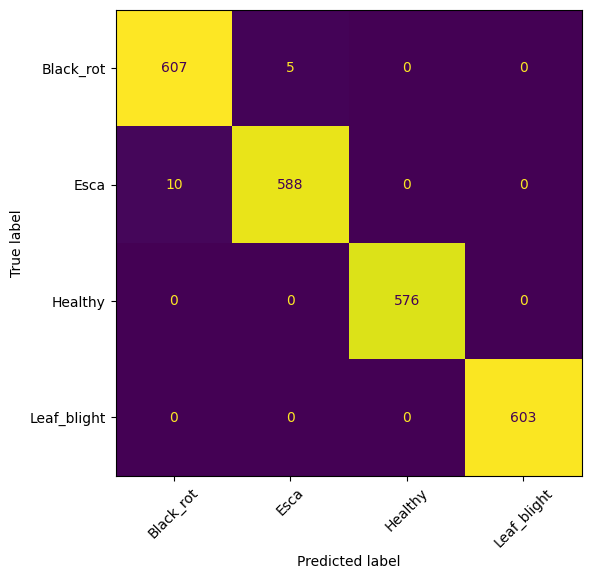

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

checkpoint = torch.load(os.path.join(OUTPUT_DIR, 'grape_disease_classifier.pt'), map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=train_dataset.classes)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout()
plt.show()

## 7. Notes / next steps

- Checkpoint is saved at `OUTPUT_DIR/grape_disease_classifier.pt` as
  `{model_state_dict, class_names, img_size, val_acc}` — enough to
  rebuild the model and run inference without this notebook. The Colab
  runtime is ephemeral, so download it (or copy it to
  `/content/drive/MyDrive/...`) before the session ends, then bring it
  back into the repo at `research/models/grape_disease_classifier.pt`
  (gitignored — copy it wherever `ml/classifier.py` expects it).
- **Swapping in real user data later**: point `DATASET_DIR` at the new
  dataset (same `train/<class>/val/<class>` layout), update
  `CLASS_NAMES` if the label set changed, and re-run from Section 3
  onward. No architecture changes needed unless class count changes.
- If `FREEZE_BACKBONE = True` plateaus below target accuracy, try
  `FREEZE_BACKBONE = False` (fine-tune the whole network) — needs a
  lower LR (e.g. `1e-5`) and more data to avoid overfitting.
- Once accuracy is acceptable, export `.pt` weights and wire up the
  `predict(image_bytes) -> PredictionResult` inference wrapper described
  in `docs/PLAN.md`'s architecture notes.